### Dataset: [Titanic_Dataset](https://drive.google.com/file/d/19O5WyC3m_FHUV9CoguCBvQ26fgXLca1q/view)

### Assignment Instructions:
1. Load the titanic dataset
2. Perform basic data exploration using info() and describe()
3. Handle missing values if necessary
4. Create the required visualizations
5. Add title and axis labels to each chart
6. Write interpretation for each visualization
7. Write final insights from the dataset.

In [4]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style('whitegrid')

# Display plots inside Google Colab
%matplotlib inline

# Load the Titanic dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Titanic.csv')

# Display first 5 rows
df.head()

# Display information about the dataset
print(df.info())

# Display summary statistics
print(df.describe())

# Check missing values in every column
print("\nMissing Values before handling:")
print(df.isnull().sum())

# Fill missing Age Values with median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked Values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin column also contains a large number of missing values but they are not required for any of the questions so we can leave it unchanged.

# Check missing values after handling age and Embarked
print("\nMissing Values after handling:")
print(df.isnull().sum())

Saving Titanic.csv to Titanic (3).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.5

### Q1. Create a countplot to show the number of passengers by gender

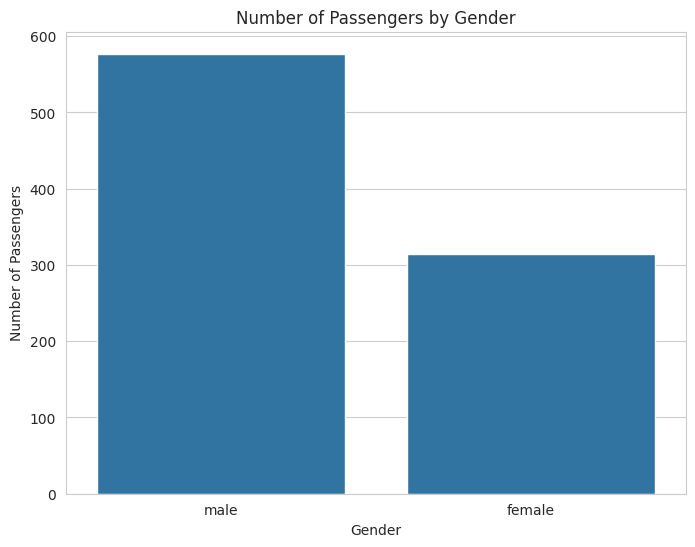

In [5]:
# Solution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sex')
plt.title('Number of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

### Interpretation
There were significantly more male passengers than female passengers.

- Male passengers = 577
- Female passengers = 314

Therefore, males represented the majority of passengers in the dataset.

### Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.

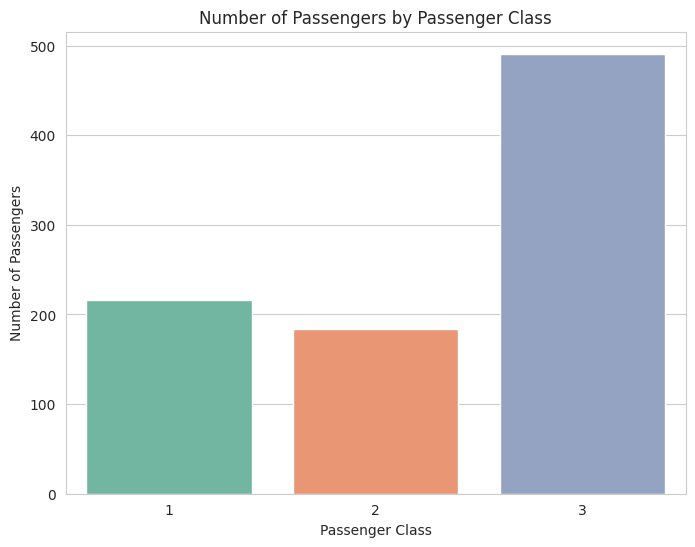

In [6]:
# Solution
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x='Pclass',
    hue= 'Pclass',
    palette='Set2',
    legend=False
)
plt.title('Number of Passengers by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

### Interpretation
Passenger Class 3 had the largest number of passengers.

|Class|	Passengers|
|---|---|
|1|	216|
|2|	184|
|3|	491|

Therefore, third-class passengers formed the largest group.

### Q3. Create a histogram to show the distribution of passenger age.

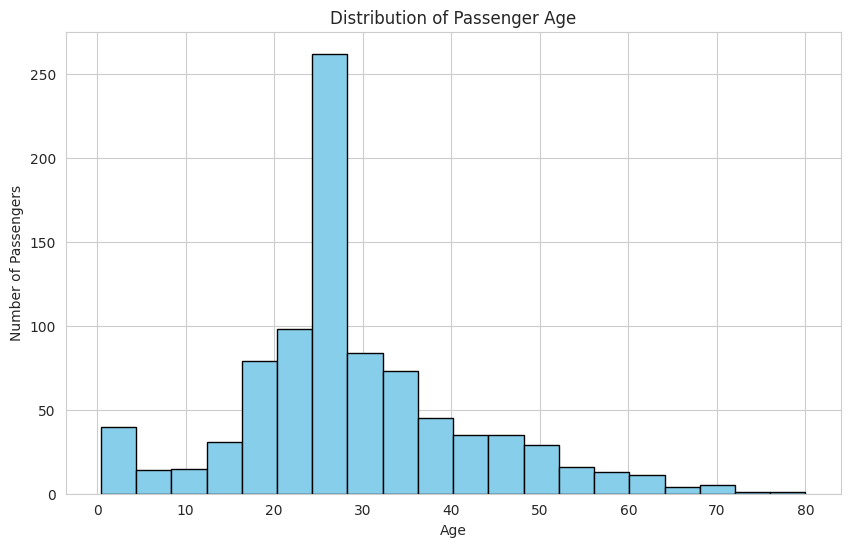

In [7]:
# Solution
plt.figure(figsize=(10, 6))
plt.hist(
    df['Age'],
    bins=20,
    color='skyblue',
    edgecolor='black'
)
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

### Interpretation
The histogram shows that most Titanic passengers were relatively young adults.

The average age is approximately 29.7 years, while the median age is 28 years.

The dataset contains passengers ranging from infants to elderly passengers, with the maximum age being 80 years.

### Q4. Create a boxplot to detect outliers in the fare column

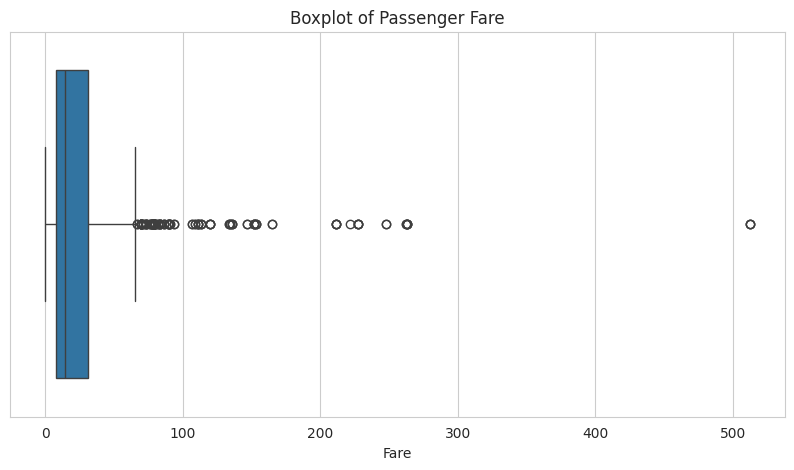

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of fare outliers: 116


In [11]:
# Solution
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Fare')
plt.title('Boxplot of Passenger Fare')
plt.xlabel('Fare')
plt.show()

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
fare_outliers = df[
    (df['Fare'] < lower_bound) |
    (df['Fare'] > upper_bound)
]

print("Number of fare outliers:", len(fare_outliers))

### Interpretation
The boxplot shows that the Fare variable contains several high-value outliers.

Most passengers paid relatively low fares, while a small number of passengers paid substantially higher fares.

The maximum fare in the dataset is approximately 512.33, which is much higher than the typical fare.

### Q5. Create a scatterplot to:
1. Show the relationship between age and fare.
2. Analyze the relationship between family size(SibSp + Parch) and fare.

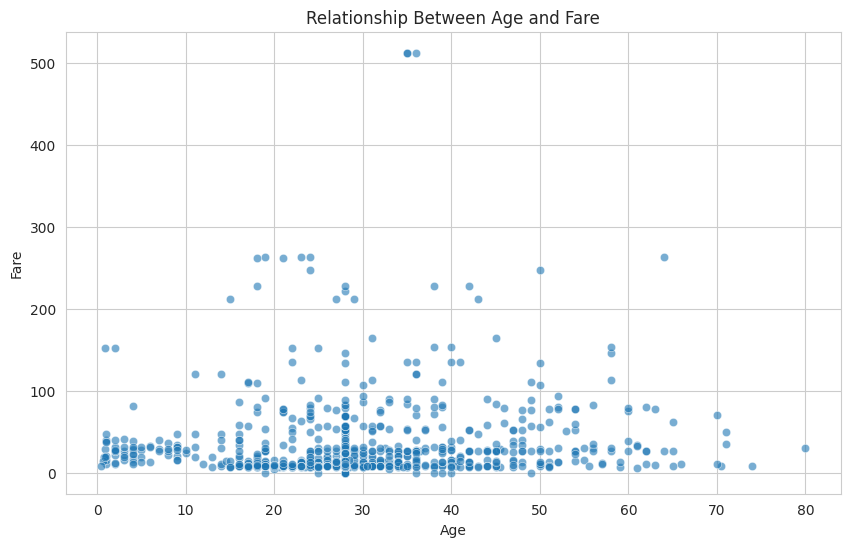

In [12]:
# Solution part 1
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    alpha=0.6
)

plt.title('Relationship Between Age and Fare')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.show()

### Interpretation part 1
The scatterplot does not show a strong direct relationship between age and fare.

Passengers of different ages paid a wide range of fares.

However, some very high fares can be observed across different age groups.

Therefore, age alone does not appear to determine the fare paid.

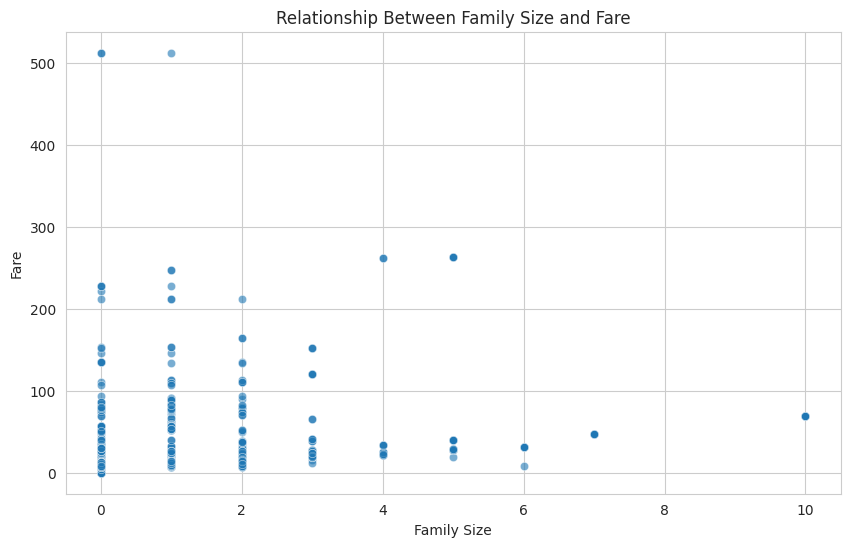

In [13]:
# Solution part 2

# Calculate family size
df['FamilySize'] = df['SibSp'] + df['Parch']

# Now create scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='FamilySize',
    y='Fare',
    alpha=0.6
)

plt.title('Relationship Between Family Size and Fare')
plt.xlabel('Family Size')
plt.ylabel('Fare')

plt.show()

### Interpretation part 2
The scatterplot shows that passengers with different family sizes paid different fares.

There is some tendency for passengers with larger family groups to have higher fares, but the relationship is not strong.

The data also contains some passengers with very high fares, which appear as outliers.

### Q6. Create a countplot to show survival count by gender.

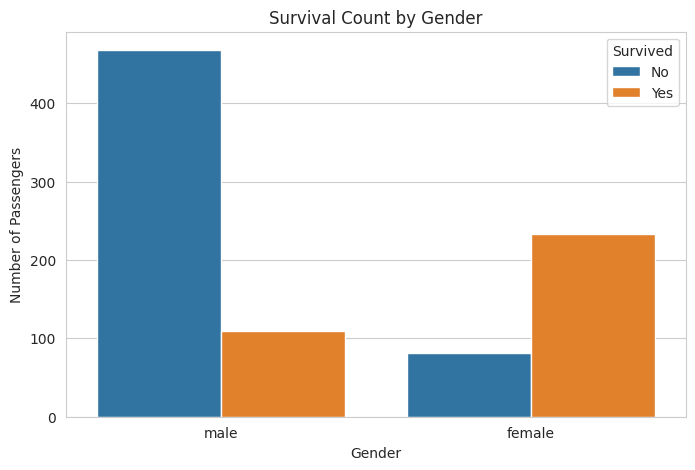

In [14]:
# Solution
plt.figure(figsize=(8, 5))

sns.countplot(
    data= df,
    x='Sex',
    hue='Survived'
)

plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.legend(
    title='Survived',
    labels=['No', 'Yes']
)

plt.show()

### Interpretation
There is a very large difference in survival between males and females.

|Gender	|Did Not Survive|	Survived|
|---|---|---|
|Female|	81|	233|
|Male|	468	|109|

Among females:

233 survived and 81 did not survive.

Among males:

109 survived and 468 did not survive.

Therefore, female passengers had a substantially higher survival count and survival proportion than male passengers.

### Q7. Create a bar chart to show survival by passenger class.

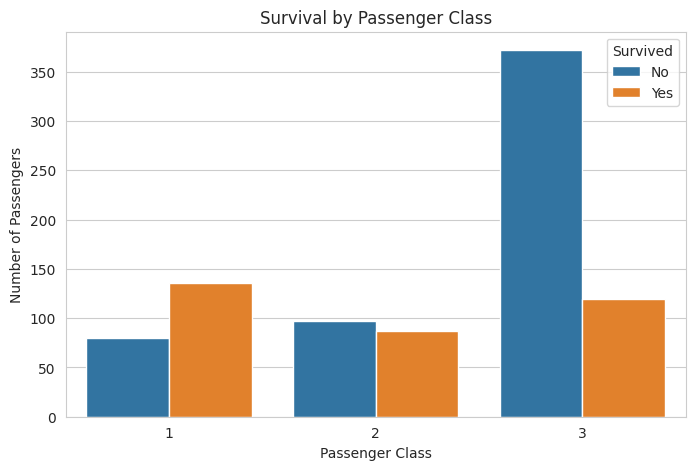

In [15]:
# Solution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.legend(
    title='Survived',
    labels=['No', 'Yes']
)

plt.show()

### Interpretation
The number of survivors differs considerably between passenger classes.

|Class|	Did Not Survive	|Survived|
|---|---|---|
|1|	80|	136|
|2|	97|	87|
|3|	372|	119|

Third-class passengers had the highest number of deaths.

First-class passengers had the highest survival proportion among the three classes.

### Q8. Create a heatmap to show correlation between numerical variables.

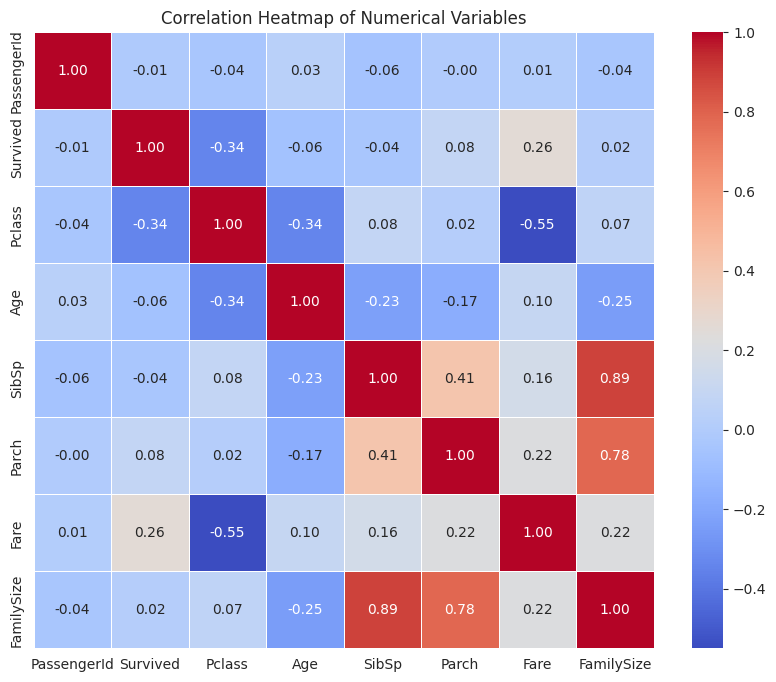

In [16]:
# Solution

# Select numerical columns
numerical_data = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numerical_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

### Important correlations

Some important correlations in the dataset are:

|Variables|	Correlation|
|---|---|
|Pclass & Fare|	-0.549|
|Pclass & Survived|	-0.338|
|Fare & Survived	|0.257|
|SibSp & Parch	|0.415|
|Age & Pclass	|-0.369|

### Interpretation
**Pclass and Fare**

There is a relatively strong negative correlation of approximately -0.549.

Since lower numerical values represent higher passenger classes, first-class passengers generally paid higher fares.

**Pclass and Survived**

The correlation is approximately -0.338.

This indicates an association between passenger class and survival.

**Fare and Survived**

The correlation is approximately 0.257.

Passengers who paid higher fares tended to have higher survival rates, although the relationship is not extremely strong.

**SibSp and Parch**

The correlation is approximately 0.415, indicating a moderate positive relationship between the number of siblings/spouses and parents/children travelling with a passenger.

### Q9. Identify which passenger class paid the highest fare on average.

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


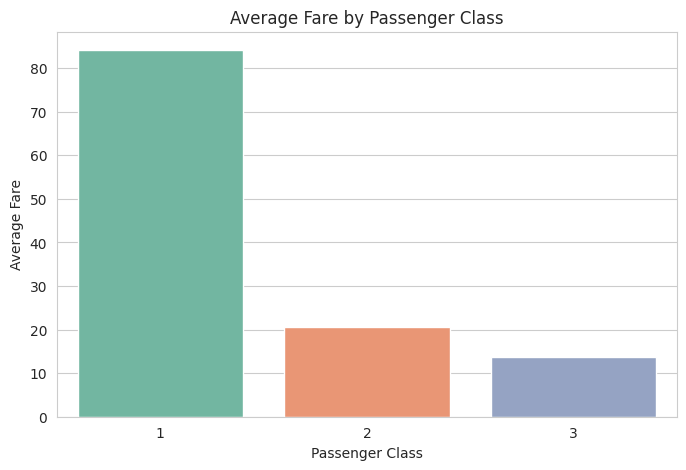

In [17]:
# Solution

# Calculate average fare for each passenger class
average_fare = df.groupby('Pclass')['Fare'].mean()

print(average_fare)

# For Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    x=average_fare.index,
    y=average_fare.values,
    hue=average_fare.index,
    palette='Set2',
    legend=False
)

plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')

plt.show()

### Interpretation
Passenger Class 1 paid the highest average fare, approximately 84.15.

This is considerably higher than the average fares of Class 2 and Class 3.

### Q10. Write at least 5 insights from the dataset based on your visualization.

### Solution

**Insight 1 — Gender Distribution**

There were 577 male passengers and 314 female passengers. Therefore, males constituted the majority of passengers in the dataset.

**Insight 2 — Passenger Class Distribution**

Third class had the largest number of passengers, with 491 passengers, compared with 216 in first class and 184 in second class.

**Insight 3 — Age Distribution**

Passenger ages ranged from approximately 0.42 to 80 years, with an average age of approximately 29.7 years. Most passengers were young or middle-aged adults.

**Insight 4 — Fare Distribution**

The fare distribution is highly right-skewed. Most passengers paid relatively low fares, while a small number paid exceptionally high fares. The maximum fare was approximately 512.33.

**Insight 5 — Gender and Survival**

Female passengers had a substantially higher survival rate than male passengers. 233 females survived compared with 109 males, while 468 males did not survive.

**Insight 6 — Passenger Class and Survival**

First-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate.

Approximate survival rates were:

- First class: 63%
- Second class: 47%
- Third class: 24%

**Insight 7 — Passenger Class and Fare**

First-class passengers paid the highest average fare, approximately 84.15, whereas third-class passengers paid approximately 13.68 on average.

**Insight 8 — Fare and Survival**

Fare has a positive correlation with survival of approximately 0.257, suggesting that passengers paying higher fares tended to have better survival outcomes.

**Insight 9 — Class and Fare**

Passenger class and fare have a correlation of approximately -0.549. Since Class 1 represents the highest passenger class and Class 3 the lowest, this reflects the substantially higher fares paid by first-class passengers.